In [1]:
import pandas as pd


In [2]:
import os
def obj_value(file):
    obj_val=None
    if os.stat(file).st_size == 0:
        obj_val='infeasible'
        return obj_val
    with open(file, 'r') as f:  
        for line in f:
            line.strip()
            if 'Objective value' in line :
                obj_val=float(line.split()[-1])
                return obj_val
    return obj_val

In [3]:
## assemble the stats from model optimized from starting point of fixed dir (only those who had a >0 growth rate ther) 
##file is save_130224
#and all the rest : models_stats_v2_free_dir
df_save=pd.read_csv('stats_csv_free/models_stats_save_130224.csv',index_col=0)
#balance warnings column retrieved other warnings than just the unbalanced reactions, get the real ones in unbalanced_stats_save_130224.csv
unbalanced_save=pd.read_csv('stats_csv_free/unbalanced_stats_save_130224.csv',index_col=0)
#if only biomass reactions are unbalanced then it's not a problem : set to 0
unbalanced_save['rxn'] = unbalanced_save['rxn'].apply(lambda x: 0 if x == 'No unbalanced rxns' or any('BIOMASS' not in element for element in x) else 1)
#Then update the column in the df_save
df_save['Balance warnings']=unbalanced_save['rxn']

#now we get the remaining modeels from models_stats_v2_free_dir
df=pd.read_csv('stats_csv_free/models_stats_v2_free_dir.csv',index_col=0)
sol_files=[f for f in os.listdir('optim/optim_free_sol/') if os.path.isfile(os.path.join('optim/optim_free_sol/', f))]
for f in sol_files:
    model_name=f.split('.')[0]
    pred=obj_value('optim/optim_free_sol/'+f)
    if type(pred)==str:
        df.loc[model_name+'.sbml','T-S optimization']=pred
    else : 
        df.loc[model_name+'.sbml','T-S optimization']=pred if abs(pred)>1e-6 else 0
for i in [model for model in df.index if model not in df_save.index]:
    df_save.loc[i]=df.loc[i]
df_processing=df_save.copy()#done


In [196]:
sol_files=[f for f in os.listdir('optim/optim_free_feastol/sol_files/') if os.path.isfile(os.path.join('optim/optim_free_feastol/sol_files/', f))]
for f in sol_files:
    model_name=f.split('.')[0]
    pred=obj_value('optim/optim_free_feastol/sol_files//'+f)
    df_processing.loc[model_name+'.sbml','T-S optimization']=pred
    

In [197]:
df_processing.to_csv('stats_csv_free/models_stats_free_preprocessed_1502.csv')

### FREE DIRECTIONS

In [204]:
###preprocess 
models_stats_free_dir=pd.read_csv('stats_csv_free/models_stats_free_preprocessed_1502.csv',index_col=0)
models_stats_free_dir['Status'].replace({'TF applied':'Thermo-model loaded and executed'},inplace=True)
models_stats_free_dir=models_stats_free_dir.rename(columns={'Failed to balance':'Not handled'})

models_stats_free_dir=models_stats_free_dir.rename(columns={'Balance warnings':'Not balanced'})
models_stats_free_dir['Status'].replace({'Not loaded':'Initialisation failed'},inplace=True)

#loading models
#if cobra failed then new cat

models_stats_free_dir.loc[models_stats_free_dir['stoichiometric optimization']==0,'Status']='Null stoichiometric optimization'

#remove very small values of TFBA optimization and make the bin 
models_stats_free_dir['T-S optimization']=models_stats_free_dir['T-S optimization'].apply(lambda x : x if  type(x)==str or abs(float(x))>1e-6  else 0)
# models_stats_free_dir['T-S optimization bin']=models_stats_free_dir['T-S optimization'].apply(lambda x: 'Growth prediction > 0' if x>0 else 'Growth prediction = 0')

#pre process not handled column 
###if the model has not handled reactions but still has a positive growth rate then set not handled to 0 
models_stats_free_dir['T-S optimization bin']=models_stats_free_dir['T-S optimization']
for i,row in models_stats_free_dir.iterrows():
    if (row['T-S optimization'])!='infeasible':
        print(row['T-S optimization'])
        if row['Not handled']>0 and float(row['T-S optimization'])>0:
            models_stats_free_dir.loc[i,'Not handled']=0
        if (row['T-S optimization'])==0 or (row['T-S optimization'])=='0':
            models_stats_free_dir.loc[i,'T-S optimization bin']='Growth prediction = 0'
        else:
            models_stats_free_dir.loc[i,'T-S optimization bin']='Growth prediction > 0'

        
    else:
        models_stats_free_dir.loc[i,'T-S optimization bin']='Infeasible'


#making bin columns 
#don't count biomass reactions as not handled 
models_stats_free_dir['Not handled bin']=pd.cut(models_stats_free_dir['Not handled'],bins=[-1,0.1,9,100],labels=['All reactions handled','1-10 reactions not handled','>10 reactions not handled'])
models_stats_free_dir['Not balanced bin']=pd.cut(models_stats_free_dir['Not balanced'],bins=[-1,0.1,10,100],labels=['All reactions balanced','1-10 reactions not balanced','>10 reactions not balanced'])



2.7400683533440207
9.44587713359633
8.50714448591959
13.175709042844794
7.588200879215787
9.786330371539979
8.680755555736352
10.74582280754086
8.19989182268982
29.582545101127216
18.17601141858238
3.1392134721609377
6.726657415705225
11.542643672926523
7.623518407068621
1.4949683109118022
2.4556921575788615
7.238365580605673
2.7167254840195403
8.507144445551539
10.590477784989705
2.396423805902452
2.2858338112071794
7.22990300821434
48.00290879789528
1.3454915266296956
0.6423821784042896
15.528350957821251
5.381365935670758
10.9377000005283
7.611809208016963
9.453149993666969
5.433108568595597
12.678807046316823
7.871321085531699
4.232563199918452
13.202952229234983
35.31836606722222
5.477736096135484
0.018253399711243137
8.190195586450841
1.700414363385372
3.3778976416255024
7.623518396985058
48.86940783636839
2.9149982061654622
7.812700118081246
2.578675336322871
7.232943312589907
30.79663231912677
17.61358069936076
8.00820111987099
50.256237990438215
4.932935427350728
7.58306994874

The df has been processed and is saved 

In [6]:
# models_stats_free_dir.to_csv('stats_csv_free/models_stats_free_end_processed_1502.csv')  
#can be loaded from this point
models_stats_free_dir=pd.read_csv('stats_csv_free/models_stats_free_processed_1502.csv',index_col=0)

By increasing the max_drG allowed in the gurobi model, models become feasible when they previously weren't - we get the new TFBA predictions for these

In [47]:
#from the previous analysis, we identified models that had a zero growth rate and models that were infeasible
zero_models=['iHN637.sbml', 'iNJ661.sbml', 'iND750.sbml', 'iIT341.sbml',
       'iMM1415.sbml', 'iAF692.sbml', 'iNF517.sbml', 'iJN746.sbml',
       'iJR904.sbml']
infeasible_models=['iAM_Pb448.sbml', 'iY75_1357.sbml', 'iYO844.sbml', 'iAM_Pv461.sbml',
       'iAM_Pk459.sbml', 'iAM_Pc455.sbml']#,'iSB619.sbml', 'iLJ478.sbml', 'iAF987.sbml', 'iAM_Pf480.sbml'] #those were done locally
files =zero_models+infeasible_models
for f in files:
    model_name=f.split('.')[0]
    pred=obj_value('optim/optim_remaining_notpos/'+f+'_1.sol')
    if type(pred)==str:
       models_stats_free_dir.loc[model_name+'.sbml','T-S optimization']=pred
    else : 
        if abs(pred)<=3e-4:
           pred=0
           models_stats_free_dir.loc[model_name+'.sbml','T-S optimization bin']='Growth prediction = 0'
        if pred>0:
           models_stats_free_dir.loc[model_name+'.sbml','T-S optimization bin']='Growth prediction > 0'
        models_stats_free_dir.loc[model_name+'.sbml','T-S optimization']=pred 

        print(model_name,pred)

iHN637 0.03312784453165364
iNJ661 15.561440310130438
iIT341 18.76455272242877
iJN746 1.4002
iJR904 0.09267027788863501
iAM_Pb448 0.16382147437421893
iY75_1357 0.001939720676671854
iYO844 0.00206750663090768
iAM_Pv461 0.15473140622454132
iAM_Pk459 0.15473140622862888
iAM_Pc455 0.1547314062204538


In [16]:
#some were done locally :'iSB619.sbml', 'iLJ478.sbml', 'iAF987.sbml', 'iAM_Pf480.sbml']
local_optim=['iSB619.sbml', 'iLJ478.sbml', 'iAF987.sbml', 'iAM_Pf480.sbml']
df_local=pd.read_csv('stats_csv_free/models_stats_save_notpos2.csv',index_col=0)
for l in local_optim:
    pred=df_local.loc[l,'T-S optimization'] if abs(df_local.loc[l,'T-S optimization'])>3e-4 else 0
    if models_stats_free_dir.loc[l,'T-S optimization']>0:
        models_stats_free_dir.loc[l,'T-S optimization bin']='Growth prediction > 0'
    else:
        models_stats_free_dir.loc[l,'T-S optimization bin']='Growth prediction = 0'
    print(l,models_stats_free_dir.loc[l,'T-S optimization'],models_stats_free_dir.loc[l,'T-S optimization bin'])

iSB619.sbml 0 Growth prediction = 0
iLJ478.sbml 0.001 Growth prediction > 0
iAF987.sbml 0.002 Growth prediction > 0
iAM_Pf480.sbml 0.1937943496418 Growth prediction > 0


In [19]:
# models_stats_free_dir.to_csv('stats_csv_free/models_stats_free_processed_remainingnotpos_2202_v2.csv')
models_stats_free_dir['Status'].value_counts()# 100 loaded
models_to_check=models_stats_free_dir[models_stats_free_dir['Status']=='Thermo-model loaded and executed'].copy()#.index.tolist()
models_to_check['Not handled bin'].value_counts() # 94 models have all reactions handled
models_to_check=models_to_check[models_to_check['Not handled bin']=='All reactions handled']
models_to_check['Not balanced bin'].value_counts() # 87 models have all reactions balanced
models_to_check=models_to_check[models_to_check['Not balanced bin']=='All reactions balanced']
models_to_check['T-S optimization bin'].value_counts() #82 models have a growth prediction >0
len(models_to_check[models_to_check['T-S optimization bin']=='Growth prediction > 0'].index.tolist())

82

### load from here

In [3]:
models_stats_free_dir=pd.read_csv('stats_csv_free/models_stats_free_processed_all_2302_vf.csv',index_col=0)
# models_stats_free_dir.to_csv('stats_csv_free/models_stats_free_processed_remainingnotpos_2202.csv')

In [4]:
#check how many models have not handled or not balanced reactions but still have a growth rate >0
print(models_stats_free_dir[(models_stats_free_dir['Not handled']>0)&(models_stats_free_dir['T-S optimization']>0)]['T-S optimization bin'].value_counts())
print(models_stats_free_dir[(models_stats_free_dir['Not balanced']>0)&(models_stats_free_dir['T-S optimization']>0)]['T-S optimization bin'].value_counts())
## to add as a value in the plot
#  [models_stats_free_dir.loc[(models_stats_free_dir['Not handled']>0)&(models_stats_free_dir['T-S optimization']>0)]['T-S optimization bin'].value_counts().loc[node_labels[i]]for i in target[9:10]]
#same for not balanced #but in fact already counted in not hanlded
[models_stats_free_dir.loc[(models_stats_free_dir['Not balanced']>0)&(models_stats_free_dir['T-S optimization']>0)]['T-S optimization bin'].value_counts().loc[node_labels[i]]for i in target[10:11]]

TypeError: '>' not supported between instances of 'str' and 'int'

In [5]:
models_stats_free_dir.loc[(models_stats_free_dir['Not balanced']==0)&(models_stats_free_dir['Not handled']==0)]['T-S optimization bin'].value_counts()

T-S optimization bin
Growth prediction > 0    82
Growth prediction = 0     5
Name: count, dtype: int64

In [6]:
[models_stats_free_dir.loc[models_stats_free_dir['Status']=='Thermo-model loaded and executed']['Not handled bin'].value_counts()]#.loc[node_labels[i]]for i in target[3:4]]


[Not handled bin
 All reactions handled                      94
 Reaction handling needs manual curation     6
 Name: count, dtype: int64]

In [8]:
##without >10 reactions ...
#making bin columns 
models_stats_free_dir['Not handled bin']=pd.cut(models_stats_free_dir['Not handled'],bins=[-1,0.1,1000],labels=['All reactions handled','Reaction handling needs manual curation'])
models_stats_free_dir['Not balanced bin']=pd.cut(models_stats_free_dir['Not balanced'],bins=[-1,0.1,1000],labels=['All reactions balanced','Reaction balancing needs manual curation'])

import plotly.graph_objects as go
node_labels= ["All models", "Thermo-model loaded and executed", "Null stoichiometric optimization", "Initialisation failed",
               "All reactions handled",'Reaction handling needs manual curation',
               'All reactions balanced','Reaction balancing needs manual curation',
                'Growth prediction = 0','Growth prediction > 0'
               ]
node_labels_with_number = [
    "All models <span style=\"color:blue;\">(107)</span>",
    "Thermo-model loaded and executed <span style=\"color:blue;\">(100)</span>",
    "Null stoichiometric optimization <span style=\"color:blue;\">(3)</span>",
    "Initialisation failed <span style=\"color:blue;\">(4)</span>",
    "All reactions* handled <span style=\"color:blue;\">(94)</span>",
    'Reaction handling needs manual curation <span style="color:blue;">(6)</span>',
    'All reactions balanced <span style="color:blue;">(87)</span>',
    'Reaction balancing needs manual curation <span style="color:blue;">(7)</span>',
    'Growth prediction = 0 <span style="color:blue;">(5)</span>',
    'Growth prediction > 0 <span style="color:blue;">(82)</span>'
] 

# x=[0,0.6,0.5,0.5,1.7,1,2.5,2.3,3.35,3.35]
# y=[0,-4.25,1,2,-4.65,-1.4,-4.72,-1.4,0.1,-5]

x=[0.01,0.5,0.2,0.2,1.5,0.8,2.2,1.85,3.4,3.4]
y=[-7,-7.1,-3,-4.5,-7.2,-4.5,-7.3,-4.5,-4.5,-7.35]

colors=['black','green','orange','red','green','orange','green','orange','orange','green']
target=[1,2,3,4,5,6,7,8,9,10]
fig=go.Figure()
fig.add_trace(go.Sankey(node = dict(
      pad = 30,
      thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = node_labels_with_number,
      x=[i*0.24 for i in x],
      y=[j*-0.1 for j in y],
      # x=x,
      #   y=y,

      color = colors
    ),
    link=dict(arrowlen=15,
        source=[0,0,0,1,1,4,4,6,6,6],
        target=target,
       value=[models_stats_free_dir['Status'].value_counts().loc[node_labels[i]]for i in target[0:3]]
       +[models_stats_free_dir.loc[models_stats_free_dir['Status']=='Thermo-model loaded and executed']['Not handled bin'].value_counts().loc[node_labels[i]]for i in target[3:5]]
       +[models_stats_free_dir.loc[(models_stats_free_dir['Not handled bin']=='All reactions handled') & (models_stats_free_dir['Status']=='Thermo-model loaded and executed') ]['Not balanced bin'].value_counts().loc[node_labels[i]]for i in target[5:7]]
       +[models_stats_free_dir.loc[(models_stats_free_dir['Not balanced bin']=='All reactions balanced')& (models_stats_free_dir['Not handled bin']=='All reactions handled')&(models_stats_free_dir['Status']=='Thermo-model loaded and executed')]['T-S optimization bin'].value_counts().loc[node_labels[i]]for i in target[7:9]]
    )
       ,textfont=dict(size=18,family='Times New Romans',color='black')
       )
       )
# Adjust the figure size in the layout
fig.update_layout(
    width=1475,  # Set the width of the figure
    height=220,
    # xaxis=dict(domain=[0, 0.7]),
    # yaxis=dict(domain=[0, 1]),
    margin=dict(l=0, r=0, t=0, b=0)
#set no margin 
    #marg#in=dict(l=1, r=1, t=1, b=1),
    # title='Automatic application of the Thermo-Flux pipeline to all BIGG models',  # Add a title to the plot
    # title_x=0.5,  # Set the x-coordinate of the title to the center of the figure (0 to 1)
    # title_y=0.3,title_font=dict(size=24,color='black', family='Times New Romans')
)

# fig.write_image("Figures/Sankey_v3_free_directions_2202.png",width=fig.layout.width, height=fig.layout.height, scale=1)
# fig.write_image("Figures/Sankey_v3_free_directions_2202.svg",width=fig.layout.width, height=fig.layout.height, scale=1)

fig.show()


Plot tfba vs FBA

In [13]:

s_tfba=models_stats_free_dir.loc[(models_stats_free_dir['Status']=='Thermo-model loaded and executed') & (models_stats_free_dir['T-S optimization bin']=='Growth prediction > 0')&(models_stats_free_dir['Not balanced bin']=='All reactions balanced')].copy()
#drop rows with infeasible t-s optimization
# index_difference = s_tfba.index.difference(models_to_check.index)
# print(index_difference)
##there is one model that does not have rxn balanced but still has a >0 growth rate
#it is still considered to be in "reaction balancing need manual curation"


PLOT TFBA vs FBA

In [14]:
### categorize organism
org=pd.read_csv('models_organisms.csv',index_col=0)
org['organism'] = [' '.join(i.split(' ')[:2]) for i in org['organism'].values]
display(org.value_counts())
org.loc[org['organism']=='Trypanosoma cruzi','group']='Flagellates'
org.loc[org['organism']=='Shigella flexneri','group']='Gram-negative bacteria'
org.loc[org['organism']=='Shigella boydii','group']='Gram-negative bacteria'
org.loc[org['organism']=='Pseudomonas putida','group']='Gram-negative bacteria'
org.loc[org['organism']=='Synechocystis sp.','group']='Cyanobacteria'
org.loc[org['organism']=='Saccharomyces cerevisiae','group']='Fungi'
#Staphylococcus aureus
org.loc[org['organism']=='Staphylococcus aureus','group']='Gram-positive bacteria'
#Mycobacterium tuberculosis     2
org.loc[org['organism']=='Mycobacterium tuberculosis','group']='Gram-positive bacteria'
org.loc[org['organism']=='Salmonella enterica','group']='Gram-negative bacteria'
org.loc[org['organism']=='Salmonella pan-reactome','group']='Gram-negative bacteria'
org.loc[org['organism']=='Acinetobacter baumannii','group']='Gram-negative bacteria'
org.loc[org['organism']=='Shigella dysenteriae','group']='Gram-negative bacteria'
org.loc[org['organism']=='Plasmodium knowlesi','group']='Protists'
org.loc[org['organism']=='Shigella sonnei','group']='Gram-negative bacteria'
org.loc[org['organism']=='Synechococcus elongatus','group']='Cyanobacteria'
org.loc[org['organism']=='Thermotoga maritima','group']='Thermophiles'
org.loc[org['organism']=='Plasmodium vivax','group']='Protists'
org.loc[org['organism']=='Plasmodium cynomolgi','group']='Protists'
org.loc[org['organism']=='Plasmodium falciparum','group']='Protists'
org.loc[org['organism']=='Bacillus subtilis','group']='Gram-positive bacteria'
org.loc[org['organism']=='Plasmodium berghei','group']='Protists'
org.loc[org['organism']=='Phaeodactylum tricornutum','group']='Protists'
org.loc[org['organism']=='Mus musculus','group']='Mammals'
org.loc[org['organism']=='Methanosarcina barkeri','group']='Archaea'
org.loc[org['organism']=='Lactococcus lactis','group']='Gram-positive bacteria'
org.loc[org['organism']=='Klebsiella pneumoniae','group']='Gram-negative bacteria'
org.loc[org['organism']=='Helicobacter pylori','group']='Gram-negative bacteria'
org.loc[org['organism']=='Geobacter metallireducens','group']='Gram-negative bacteria'
org.loc[org['organism']=='Cricetulus griseus','group']='Mammals'
org.loc[org['organism']=='Clostridium ljungdahlii','group']='Gram-positive bacteria'
org.loc[org['organism']=='Clostridioides difficile','group']='Gram-positive bacteria'
org.loc[org['organism']=='Chlamydomonas reinhardtii','group']='Protists'
org.loc[org['organism']=='Yersinia pestis','group']='Gram-negative bacteria'
#Homo sapiens                   
org.loc[org['organism']=='Homo sapiens']='Mammals'
org.loc[org['organism']=='Escherichia coli']='E. Coli'

organism                  
Escherichia coli              58
Homo sapiens                   4
Trypanosoma cruzi              4
Shigella flexneri              4
Shigella boydii                2
Pseudomonas putida             2
Synechocystis sp.              2
Saccharomyces cerevisiae       2
Staphylococcus aureus          2
Mycobacterium tuberculosis     2
Salmonella enterica            1
Salmonella pan-reactome        1
Acinetobacter baumannii        1
Shigella dysenteriae           1
Plasmodium knowlesi            1
Shigella sonnei                1
Synechococcus elongatus        1
Thermotoga maritima            1
Plasmodium vivax               1
Plasmodium cynomolgi           1
Plasmodium falciparum          1
Bacillus subtilis              1
Plasmodium berghei             1
Phaeodactylum tricornutum      1
Mus musculus                   1
Methanosarcina barkeri         1
Lactococcus lactis             1
Klebsiella pneumoniae          1
Helicobacter pylori            1
Geobacter metall

In [15]:
#show more rows
pd.set_option('display.max_rows', 100)
s_tfba.index=[s.split('.')[0] for s in s_tfba.index]
s_tfba['Organism']=org['organism']
s_tfba['group']=org['group']

In [16]:
pd.set_option('display.max_rows', 10)
s_tfba['T-S optimization'] = s_tfba['T-S optimization'].astype(float)
s_tfba['stoichiometric optimization'] = s_tfba['stoichiometric optimization'].astype(float)


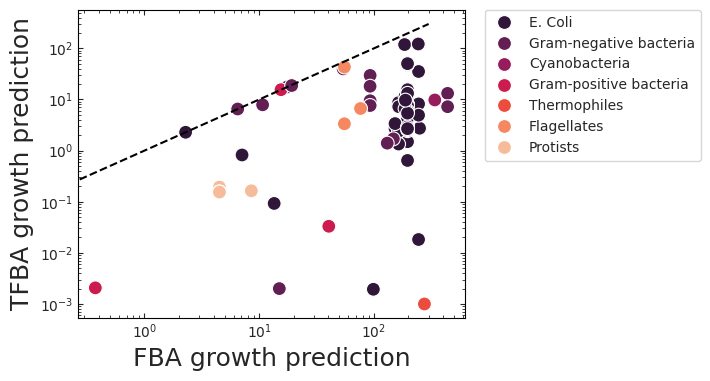

In [17]:
#scatter t-s optim vs stoichiometric optimization#hide legend
#make the sns plot look better
import seaborn as sns
import matplotlib.pyplot as plt
import scienceplots
#grid =none
sns.set_style("whitegrid")
#get rid of the grid
sns.set_style("ticks")
#set the palette

fig = plt.gcf()

fig.set_size_inches(5,4)
sns.scatterplot(data=s_tfba, y='T-S optimization', x='stoichiometric optimization',hue='group',s=100,palette='rocket')

#plot y=x line
plt.plot([0,300],[0,300],color='black',linestyle='--')

# #make it look good
plt.title('',y=1.05)
#put the title a bit higher

plt.ylabel('TFBA growth prediction',fontsize=18)
plt.xlabel('FBA growth prediction',fontsize=18)

#legend 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.xscale('log')
plt.yscale('log')  
# # plt.ylim(0, 200)
# plt.xlim(0,600)  
#frames in black
ax = plt.gca()
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['top'].set_color('black')

ax.spines['right'].set_color('black')
ax.tick_params(direction='in',reset=True)
# Set secondary x-axis ticks inside the axes
ax.xaxis.set_tick_params(which='both', direction='in', reset=True)

# Set secondary y-axis ticks inside the axes
ax.yaxis.set_tick_params(which='both', direction='in', reset=True)

# Set y-axis direction to go up

# plt.savefig('Figures/freedir_scatter_grouped_TFBAvsFBA.png',dpi=300,bbox_inches='tight')


## plot FBA fixed vs TBFA free

In [4]:
##attribute group and organism to the models
df_fixed=pd.read_csv('models_stats_v2_fixed_dir.csv',index_col=0)
df_fixed.index=[s.split('.')[0] for s in df_fixed.index]
df_fixed['Organism']=org['organism']
df_fixed['group']=org['group']
df_fixed.index=[s+'.sbml' for s in df_fixed.index]


FileNotFoundError: [Errno 2] No such file or directory: 'models_stats_v2_fixed_dir.csv'

In [28]:
## same plot but with 
fixed_tfba=df_fixed.loc[[s+'.sbml' for s in s_tfba.index]]
fixed_tfba.index=[s.split('.')[0] for s in fixed_tfba.index]
s_tfba['fixed stoichiometric optimization']=fixed_tfba['stoichiometric optimization']

In [29]:
s_tfba

,Status,stoichiometric optimization,Not handled,Biomass reactions,atom bag unbalanced rxns,Not balanced,T-S optimization,Organism,T-S optimization bin,Not handled bin,Not balanced bin,group,fixed stoichiometric optimization
iEC1364_W,Thermo-model loaded and executed,250.037034,0.0,0.0,278.0,0.0,2.740068,E. Coli,Growth prediction > 0,All reactions handled,All reactions balanced,E. Coli,0.992753
iECS88_1305,Thermo-model loaded and executed,196.359021,0.0,0.0,244.0,0.0,9.445877,E. Coli,Growth prediction > 0,All reactions handled,All reactions balanced,E. Coli,0.982478
iECSE_1348,Thermo-model loaded and executed,196.359021,0.0,0.0,236.0,0.0,8.507144,E. Coli,Growth prediction > 0,All reactions handled,All reactions balanced,E. Coli,0.982478
iS_1188,Thermo-model loaded and executed,438.981563,0.0,0.0,227.0,0.0,13.175709,Shigella flexneri,Growth prediction > 0,All reactions handled,All reactions balanced,Gram-negative bacteria,0.857077
iEcolC_1368,Thermo-model loaded and executed,196.359021,0.0,0.0,243.0,0.0,7.588201,E. Coli,Growth prediction > 0,All reactions handled,All reactions balanced,E. Coli,0.982478
...,...,...,...,...,...,...,...,...,...,...,...,...,...
iAM_Pv461,Thermo-model loaded and executed,4.504505,0.0,3.0,106.0,0.0,0.154731,Plasmodium vivax,Growth prediction > 0,All reactions handled,All reactions balanced,Protists,0.687175
iAM_Pk459,Thermo-model loaded and executed,4.504505,0.0,3.0,106.0,0.0,0.154731,Plasmodium knowlesi,Growth prediction > 0,All reactions handled,All reactions balanced,Protists,0.687175
iJN746,Thermo-model loaded and executed,130.652859,0.0,3.0,54.0,0.0,1.400200,Pseudomonas putida,Growth prediction > 0,All reactions handled,All reactions balanced,Gram-negative bacteria,1.400000
iAM_Pc455,Thermo-model loaded and executed,4.504505,0.0,3.0,105.0,0.0,0.154731,Plasmodium cynomolgi,Growth prediction > 0,All reactions handled,All reactions balanced,Protists,0.658701


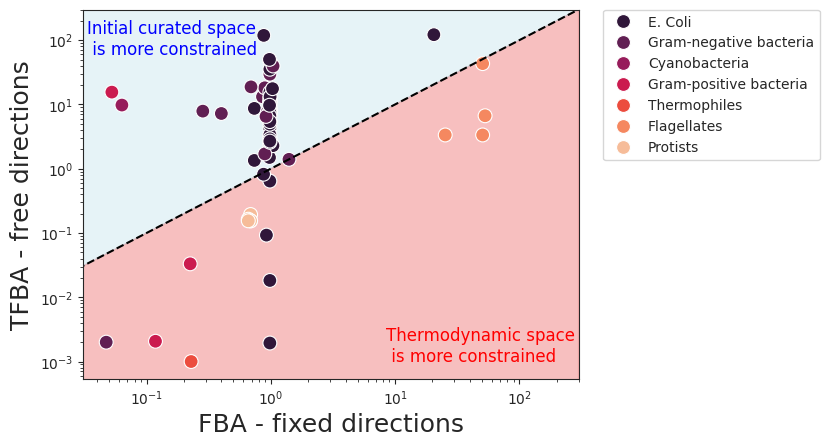

In [70]:

#plot y=x line
plt.plot([0,300],[0,300],color='black',linestyle='--')

# Color the area below the curve in light red
plt.fill_between([0, 300], [0, 300], color='lightcoral', alpha=0.5)

# Color the area above the curve in light blue
plt.fill_between([0, 300], [0, 300], 300, color='lightblue', alpha=0.3)
sns.scatterplot(data=s_tfba, y='T-S optimization', x='fixed stoichiometric optimization',hue='group',s=100,palette='rocket')

# Format
plt.ylabel('TFBA - free directions',fontsize=18)
plt.xlabel('FBA - fixed directions',fontsize=18)
plt.xscale('log')
plt.yscale('log')
ax = plt.gca()
xmin,xmax=ax.get_xlim()
ymin,ymax=ax.get_ylim()
plt.xlim(xmin,300)
plt.ylim(ymin,300)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

# Add text annotations below and above the curve
plt.text(8.5, 1e-3, 'Thermodynamic space \n is more constrained', color='red', fontsize=12)
plt.text(3.3e-2, 6e1, 'Initial curated space \n is more constrained', color='blue', fontsize=12)
# plt.savefig('Figures/fbafixed_vs_tfbafree_directions.png',dpi=300,bbox_inches='tight')

In [ ]:
, 1e2, 'Initial curated space is more constrained', color='blue', fontsize=10)


In [66]:
sns.color_palette("rocket")


[(0.20973515, 0.09747934, 0.24238489),
 (0.43860848, 0.12177004, 0.34119475),
 (0.67824099, 0.09192342, 0.3504148),
 (0.8833417, 0.19830556, 0.26014181),
 (0.95381595, 0.46373781, 0.31769923),
 (0.96516917, 0.70776351, 0.5606593)]

In [131]:
#mround T-S optimization to the nearest 0.01
s_tfba['T-S optimization round']=s_tfba['T-S optimization'].apply(lambda x: round(x,2))
s_tfba[s_tfba['Organism']=='Escherichia coli'].value_counts('T-S optimization round')

T-S optimization round
0.42    24
0.00     2
6.69     2
0.32     1
0.36     1
0.37     1
0.38     1
0.41     1
6.61     1
7.66     1
dtype: int64

### models with prediction done without ignoring proton transport

In [25]:
##which models were done without ignoring proton transport
sol_files=[f for f in os.listdir('optim/optim_free_sol/') if os.path.isfile(os.path.join('optim/optim_free_sol/', f))]
for f in sol_files:
    model_name=f.split('.')[0]
    pred=obj_value('optim/optim_free_sol/'+f)
    if type(pred)!=str:
        if pred>1e-5:
            print(model_name,pred)

iYL1228 0.3990604264666858
iIS312_Epimastigote 3.35158249925034
iEC1364_W 0.4830267946676424
iIS312_Amastigote 3.351582310784951
iPC815 0.2835583813431892
iEC1344_C 0.45390038316441833
iAF1260b 0.3490542966033922
iIS312 3.3515851159574397
iEC1349_Crooks 0.4727663738039873
e_coli_core 0.8214783735549682
iEC1368_DH5a 0.4695194029769162
iJO1366 0.4625463557189163
iEC1356_Bl21DE3 0.45577514999753005
iAF1260 0.33886625925105895
iML1515 0.3533781806936531
iIS312_Trypomastigote 6.668630021289977
iYS854 108.46763783357086


In [38]:
i=['iYL1228','iEC1364_W','iPC815','iEC1344_C','iAF1260b','iIS312','iEC1368_DH5a','iJO1366','iEC1356_Bl21DE3','iAF1260','iML1515']#,'iYS854']# not in the fully parameterized models
# i=[i+'.sbml' for i in i]    

todo # 2202 # all of these ['iYL1228.sbml',
 'iEC1364_W.sbml',
 'iPC815.sbml',
 'iEC1344_C.sbml',
 'iAF1260b.sbml',
 'iIS312.sbml',
 'iEC1368_DH5a.sbml',
 'iJO1366.sbml',
 'iEC1356_Bl21DE3.sbml',
 'iAF1260.sbml',
 'iML1515.sbml',
 'iYS854.sbml'] # 
 have to be optimized again to check value

In [56]:
check_again_df=pd.read_csv('models_stats_save_check_again_ignore2nd.csv',index_col=0)
for i, row in check_again_df.iterrows():
    # print(i,row['T-S optimization'])
    pred=float(row['T-S optimization'])
    if type(row['T-S optimization'])!=str:
        if pred>float(models_stats_free_dir.loc[i,'T-S optimization']):
            models_stats_free_dir.loc[i,'T-S optimization']=pred
            models_stats_free_dir.loc[i,'T-S optimization bin']='Growth prediction > 0'
            print(i,pred)


iYL1228.sbml 39.683
iIS312.sbml 43.202


In [57]:
# models_stats_free_dir.to_csv('stats_csv_free/models_stats_free_processed_all_2302_vf.csv')